In [1]:
from pathlib import Path
import gc
import json
import shutil
import sys
import zipfile

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import sklearn


In [2]:
DATA_DIR = Path("data")
MODEL_DIR = DATA_DIR/"model_handoff"

In [3]:
def get_metadata():
    with open(MODEL_DIR / "handoff_metadata.json") as f:
        metadata = json.load(f)
    return metadata

In [4]:
train_df = pd.read_csv(MODEL_DIR / "train_features.csv")
metadata = get_metadata()

model_feature_sets = metadata["recommended_feature_sets"]
all_model_features = metadata["all_feature_columns"]

X_train = train_df[all_model_features]
y_train = train_df["target"]
groups_train = train_df["split_group"].astype(str)

In [5]:
from sklearn.model_selection import StratifiedGroupKFold

# Initialize StratifiedGroupKFold to ensure two things:
# 1. Stratified: Each fold maintains roughly the same proportion of Smooth/Bumpy windows.
# 2. Grouped: Windows from the same parent session are kept together (no data leakage).
group_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Pre-calculate the splits to keep them deterministic and reusable across different models
cv_splits = list(group_cv.split(X_train, y_train, groups_train))

fold_rows = []

for fold_number, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    val_labels = y_train.iloc[val_idx]

    fold_rows.append({
        "Fold": fold_number,
        "Training windows": len(train_idx),
        "Validation windows": len(val_idx),
        "Validation Smooth": (val_labels == 0).sum(),
        "Validation Bumpy": (val_labels == 1).sum(),
        "Recordings held out": ", ".join(sorted(set(groups_train.iloc[val_idx]))),
    })

fold_summary_df = pd.DataFrame(fold_rows)

display(fold_summary_df)

,Fold,Training windows,Validation windows,Validation Smooth,Validation Bumpy,Recordings held out
0,1,2739,572,358,214,"Raw002, Raw010, Raw016"
1,2,2313,998,677,321,AnnotatedSession02
2,3,2880,431,186,245,"Raw005, Raw013, Raw025, Raw028"
3,4,2936,375,156,219,"Raw004, Raw007, Raw019, Raw042"
4,5,2376,935,630,305,AnnotatedSession01


In [6]:
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, fbeta_score

def init_scoring_metrics():
    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "specificity": make_scorer(recall_score, pos_label=0),
        "f0_5": make_scorer(fbeta_score, beta=0.5),
        "f1": "f1",
        "f2": make_scorer(fbeta_score, beta=2),
        "balanced_accuracy": "balanced_accuracy",
        "roc_auc": "roc_auc",
        "average_precision": "average_precision"
    }
    return scoring

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

def init_model_pipelines(learning_type):
    pipelines = {}
    
    if learning_type == "Supervised":
        pipelines = {
            "kNN": Pipeline([("scaler", StandardScaler()),("model", KNeighborsClassifier())]),
            "LogisticRegression": Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(solver="liblinear", max_iter=2000, random_state=10))]),
            "DecisionTree": Pipeline([("model", DecisionTreeClassifier(random_state=10))]),
            "RandomForest": Pipeline([("model", RandomForestClassifier(random_state=10, n_jobs=1))]),
        }

    elif learning_type == "Unsupervised":
        # All clustering algorithms are distance-based, so every feature is scaled first
        pipelines = {
            "KMeans": Pipeline([("scaler", StandardScaler()),("model", KMeans(n_init=10, random_state=10))]),
            "DBSCAN": Pipeline([("scaler", StandardScaler()),("model", DBSCAN())]),
            "GaussianMixture": Pipeline([("scaler",  StandardScaler()),("model", GaussianMixture(max_iter=2000, random_state=10))]),
            "AgglomerativeClustering": Pipeline([("scaler", StandardScaler()),("model", AgglomerativeClustering())]),
        }

    return pipelines

In [8]:
def init_model_hyperparameters(learning_type):
    hyperparameters = {}

    if learning_type == "Supervised":
        hyperparameters =  {
            "kNN": {
                "scaler": ["passthrough", StandardScaler(), RobustScaler(), MinMaxScaler(), PowerTransformer()],
                "model__n_neighbors": list(range(3, 51, 2)), 
                "model__weights": ["uniform", "distance"],
                "model__p": [1, 2]  # 1: Manhattan distance, 2: Euclidean distance
            },
            "LogisticRegression": {
                "scaler": ["passthrough", StandardScaler(), RobustScaler(), MinMaxScaler(), PowerTransformer()],
                "model__C": [0.01, 0.1, 1.0, 10.0]  # Inverse regularization strength
            },
            "DecisionTree": {
                "model__max_depth": [2, 3, 4, 5, 6, 8, 10, 12, 15, None],
                "model__min_samples_leaf": [1, 2, 5, 10, 20, 30, 50, 100]
            },
            "RandomForest": {
                "model__n_estimators": [100, 200],
                "model__max_depth": [3, 5, 8, 10, 15, 20, None],
                "model__min_samples_leaf": [1, 2, 5, 10, 20, 50]
            }
        }

    elif learning_type == "Unsupervised":
        hyperparameters = {
            "KMeans": {
                "scaler": [ StandardScaler(), RobustScaler(), MinMaxScaler(), PowerTransformer()],
                "model__n_clusters": [2, 3, 4, 5, 6]
            },
            "DBSCAN": {
                "scaler": [ StandardScaler(), RobustScaler(), MinMaxScaler(), PowerTransformer()],
                "model__eps": [0.3, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0],  # Neighbourhood radius in scaled feature units
                "model__min_samples": [5, 10, 20, 50]  # Points needed nearby to form a dense core
            },
            "GaussianMixture": {
                "scaler": [ StandardScaler(), RobustScaler(), MinMaxScaler(), PowerTransformer()],
                "model__n_components": [2, 3, 4, 5, 6],
                "model__covariance_type": ["full", "diag", "tied", "spherical"]  # Shape of each cluster
            },
            "AgglomerativeClustering": {
                "scaler": [ StandardScaler(), RobustScaler(), MinMaxScaler(), PowerTransformer()],
                "model__n_clusters": [2, 3, 4, 5, 6],
                "model__linkage": ["ward", "complete", "average"]  # How the distance between two clusters is measured
            }
        }

    return hyperparameters

In [9]:
from sklearn.metrics import precision_score, accuracy_score
from sklearn.model_selection import cross_val_predict

def find_best_threshold(model, X, y, cv):

    proba = cross_val_predict(model, X, y, cv=cv,method="predict_proba", n_jobs=-1)[:, 1] ## we want probability of bumpy class

    threshold, best_evaluation_metric_score = 0.5, 0 ## Initially threshold is 0.5
    beta_value = 0.5

    for t in np.arange(0.05, 0.96, 0.01):
        if evaluation_metric in ["f1", "f0_5", "f2"]:
            if evaluation_metric == "f1":
                beta_value = 1
            elif evaluation_metric == "f0_5":
                beta_value = 0.5
            elif evaluation_metric == "f2":
                beta_value = 2
            
            score = fbeta_score(y, (proba >= t).astype(int), beta=beta_value)

        elif evaluation_metric == "precision":
            score = precision_score(y, (proba >= t).astype(int))

        else:
            score = accuracy_score(y, (proba >= t).astype(int))
        
        if score > best_evaluation_metric_score:
            threshold, best_evaluation_metric_score = t, score

    return round(threshold, 2), best_evaluation_metric_score

In [10]:
## Start GridSearchCV for supervised

from sklearn.model_selection import GridSearchCV


model_features_data = metadata["recommended_feature_sets"]
scoring = init_scoring_metrics()
model_pipelines = init_model_pipelines("Supervised")
model_hyperparameters = init_model_hyperparameters("Supervised")

best_rows = []
evaluation_metric = "f0_5"

for model_name in model_pipelines:
    print('---------------------------------------------------')
    print(f'Running the GridSearchCV for {model_name}')
    print('---------------------------------------------------')

    pipeline = model_pipelines[model_name]
    hyperparameter = model_hyperparameters[model_name]

    for feature_set_name in model_features_data:
        print(f"\nFeature set: {feature_set_name}")

        feature_columns = model_features_data[feature_set_name]
        search = GridSearchCV(
                estimator=pipeline,
                param_grid=hyperparameter,
                scoring=scoring,
                refit=evaluation_metric,
                cv=cv_splits,
                n_jobs=-1,
                return_train_score=True)

        search.fit(train_df[feature_columns], y_train)

        # Cross-validation metrics of the best hyperparameter configuration (selected by evaluation_metric)
        best_idx = search.best_index_
        row = {"model": model_name, "feature_set": feature_set_name, "params": search.best_params_, "estimator": search.best_estimator_}
        
        # for score in scoring:
        #     row[f"mean_test_{score}"] = search.cv_results_[f"mean_test_{score}"][best_idx]

        # Threshold that maximises {evaluation_metric} for this best configuration
        best_threshold, best_evaluation_metric_score = find_best_threshold(search.best_estimator_, train_df[feature_columns], y_train, cv_splits)
        row["best_threshold"] = best_threshold
        row[f"{evaluation_metric}_at_threshold"] = best_evaluation_metric_score

        best_rows.append(row)

best_supervised_results_df = pd.DataFrame(best_rows)
display(best_supervised_results_df)

---------------------------------------------------
Running the GridSearchCV for kNN
---------------------------------------------------

Feature set: full_12

Feature set: compact_physics_5

Feature set: compact_ratio_4
---------------------------------------------------
Running the GridSearchCV for LogisticRegression
---------------------------------------------------

Feature set: full_12

Feature set: compact_physics_5


/opt/homebrew/Caskroom/miniconda/base/envs/dna/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



Feature set: compact_ratio_4


/opt/homebrew/Caskroom/miniconda/base/envs/dna/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


---------------------------------------------------
Running the GridSearchCV for DecisionTree
---------------------------------------------------

Feature set: full_12

Feature set: compact_physics_5

Feature set: compact_ratio_4
---------------------------------------------------
Running the GridSearchCV for RandomForest
---------------------------------------------------

Feature set: full_12

Feature set: compact_physics_5

Feature set: compact_ratio_4


,model,feature_set,params,estimator,best_threshold,f0_5_at_threshold
0,kNN,full_12,"{'model__n_neighbors': 49, 'model__p': 2, 'mod...","(passthrough, KNeighborsClassifier(n_neighbors...",0.71,0.836124
1,kNN,compact_physics_5,"{'model__n_neighbors': 47, 'model__p': 1, 'mod...","(PowerTransformer(), KNeighborsClassifier(n_ne...",0.83,0.847917
2,kNN,compact_ratio_4,"{'model__n_neighbors': 49, 'model__p': 1, 'mod...","(PowerTransformer(), KNeighborsClassifier(n_ne...",0.80,0.846675
3,LogisticRegression,full_12,"{'model__C': 0.1, 'scaler': RobustScaler()}","(RobustScaler(), LogisticRegression(C=0.1, max...",0.68,0.854839
4,LogisticRegression,compact_physics_5,"{'model__C': 0.01, 'scaler': RobustScaler()}","(RobustScaler(), LogisticRegression(C=0.01, ma...",0.60,0.825472
5,LogisticRegression,compact_ratio_4,"{'model__C': 10.0, 'scaler': StandardScaler()}","(StandardScaler(), LogisticRegression(C=10.0, ...",0.64,0.828740
6,DecisionTree,full_12,"{'model__max_depth': 4, 'model__min_samples_le...","(DecisionTreeClassifier(max_depth=4, min_sampl...",0.90,0.828287
7,DecisionTree,compact_physics_5,"{'model__max_depth': 3, 'model__min_samples_le...","(DecisionTreeClassifier(max_depth=3, min_sampl...",0.74,0.818315
8,DecisionTree,compact_ratio_4,"{'model__max_depth': 3, 'model__min_samples_le...","(DecisionTreeClassifier(max_depth=3, min_sampl...",0.74,0.823119
9,RandomForest,full_12,"{'model__max_depth': 3, 'model__min_samples_le...","((DecisionTreeClassifier(max_depth=3, max_feat...",0.74,0.846709


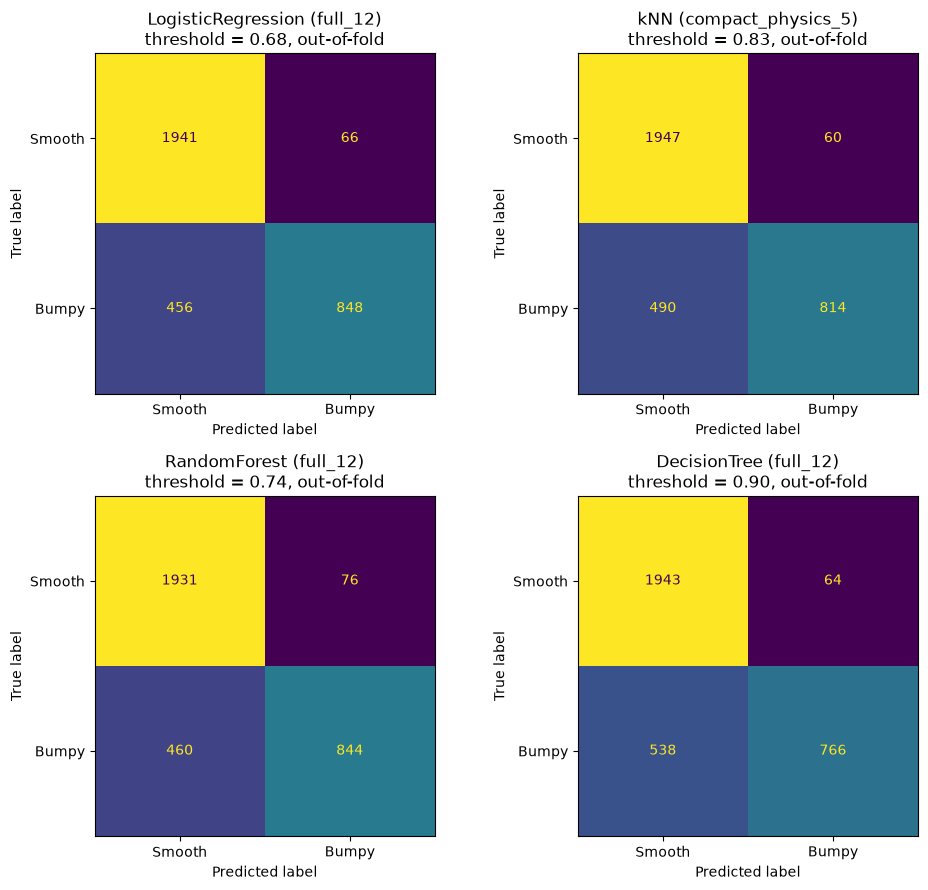

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Best configuration of each model family, ranked by the evaluation metric at its tuned threshold
best_per_model = (best_supervised_results_df
                  .sort_values(f"{evaluation_metric}_at_threshold", ascending=False)
                  .groupby("model", sort=False)
                  .head(1))

figure, subplot_grid = plt.subplots(2, 2, figsize=(10, 9))

for subplot, best_model in zip(subplot_grid.ravel(), best_per_model.itertuples()):

    train_features = train_df[model_features_data[best_model.feature_set]]

    # Each window predicted by a model trained on the other folds
    bumpy_probabilities = cross_val_predict(best_model.estimator, train_features, y_train,
                                            cv=cv_splits, method="predict_proba", n_jobs=-1)[:, 1]
    
    predicted_labels = (bumpy_probabilities >= best_model.best_threshold).astype(int)

    confusion = confusion_matrix(y_train, predicted_labels, labels=[0, 1])
    ConfusionMatrixDisplay(confusion, display_labels=["Smooth", "Bumpy"]).plot(
        ax=subplot, colorbar=False, values_format="d")
    subplot.set_title(f"{best_model.model} ({best_model.feature_set})\n"
                      f"threshold = {best_model.best_threshold:.2f}, out-of-fold")

plt.tight_layout()
plt.show()


# Unsupervised learning

In [13]:
## Start ParameterGrid search for unsupervised

from sklearn.model_selection import ParameterGrid
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score


def evaluate_clustering(scaled_features, cluster_labels, y):
    # DBSCAN marks noise points as -1, they are left out of the silhouette
    is_clustered = cluster_labels != -1
    n_clusters = len(set(cluster_labels[is_clustered]))

    silhouette = np.nan
    if n_clusters >= 2:
        silhouette = silhouette_score(scaled_features[is_clustered], cluster_labels[is_clustered])

    # Label every cluster with its majority terrain, so metrics can be compared with supervised
    terrain_per_window = pd.Series(y.to_numpy())
    terrain_by_cluster = terrain_per_window.groupby(cluster_labels)
    majority_terrain = terrain_by_cluster.agg(lambda terrain: terrain.mode()[0])

    mapped_labels = majority_terrain.loc[cluster_labels].to_numpy()


    return {
        "n_clusters": n_clusters,
        "noise_fraction": (~is_clustered).mean(),
        "silhouette": silhouette,
        "ARI": adjusted_rand_score(y, cluster_labels),
        "NMI": normalized_mutual_info_score(y, cluster_labels),
        "mapped_precision": precision_score(y, mapped_labels, zero_division=0),
        "mapped_f0_5": fbeta_score(y, mapped_labels, beta=0.5, zero_division=0),
        "mapped_f1": fbeta_score(y, mapped_labels, beta=1, zero_division=0),
        "mapped_accuracy": accuracy_score(y, mapped_labels),
    }

model_features_data = metadata["recommended_feature_sets"]
model_pipelines = init_model_pipelines("Unsupervised")
model_hyperparameters = init_model_hyperparameters("Unsupervised")

cluster_rows = []

for model_name in model_pipelines:
    print('---------------------------------------------------')
    print(f'Running the ParameterGrid search for {model_name}')
    print('---------------------------------------------------')

    pipeline = model_pipelines[model_name]
    hyperparameter = model_hyperparameters[model_name]

    for feature_set_name in model_features_data:
        print(f"\nFeature set: {feature_set_name}")

        feature_columns = model_features_data[feature_set_name]

        # Try every hyperparameter combination, the terrain labels are only used afterwards for evaluation
        for params in ParameterGrid(hyperparameter):
            pipeline.set_params(**params)
            cluster_labels = pipeline.fit_predict(train_df[feature_columns])
            scaled_features = pipeline.named_steps["scaler"].transform(train_df[feature_columns])

            row = {"model": model_name, "feature_set": feature_set_name, "params": params}
            row.update(evaluate_clustering(scaled_features, cluster_labels, y_train))
            cluster_rows.append(row)

cluster_results_df = pd.DataFrame(cluster_rows)

# Best configuration of each model, chosen by silhouette so the selection does not use the terrain labels
best_cluster_results_df = (cluster_results_df
                           .sort_values(f"mapped_{evaluation_metric}", ascending=False)
                           .groupby("model", sort=False)
                           .head(1))
display(best_cluster_results_df)

---------------------------------------------------
Running the ParameterGrid search for KMeans
---------------------------------------------------

Feature set: full_12

Feature set: compact_physics_5

Feature set: compact_ratio_4
---------------------------------------------------
Running the ParameterGrid search for DBSCAN
---------------------------------------------------

Feature set: full_12

Feature set: compact_physics_5

Feature set: compact_ratio_4
---------------------------------------------------
Running the ParameterGrid search for GaussianMixture
---------------------------------------------------

Feature set: full_12

Feature set: compact_physics_5

Feature set: compact_ratio_4
---------------------------------------------------
Running the ParameterGrid search for AgglomerativeClustering
---------------------------------------------------

Feature set: full_12

Feature set: compact_physics_5

Feature set: compact_ratio_4


,model,feature_set,params,n_clusters,noise_fraction,silhouette,ARI,NMI,mapped_precision,mapped_f0_5,mapped_f1,mapped_accuracy
515,GaussianMixture,compact_physics_5,"{'model__covariance_type': 'diag', 'model__n_c...",6,0.000000,0.238873,0.181003,0.245763,0.919203,0.856138,0.776252,0.847478
775,AgglomerativeClustering,compact_ratio_4,"{'model__linkage': 'ward', 'model__n_clusters'...",6,0.000000,0.267632,0.215799,0.250205,0.921166,0.851637,0.765022,0.841740
51,KMeans,compact_ratio_4,"{'model__n_clusters': 4, 'scaler': PowerTransf...",4,0.000000,0.352039,0.250423,0.265978,0.909375,0.848561,0.771201,0.843552
219,DBSCAN,compact_physics_5,"{'model__eps': 0.75, 'model__min_samples': 50,...",2,0.156146,0.449032,0.432906,0.331029,0.807662,0.801140,0.791553,0.839021


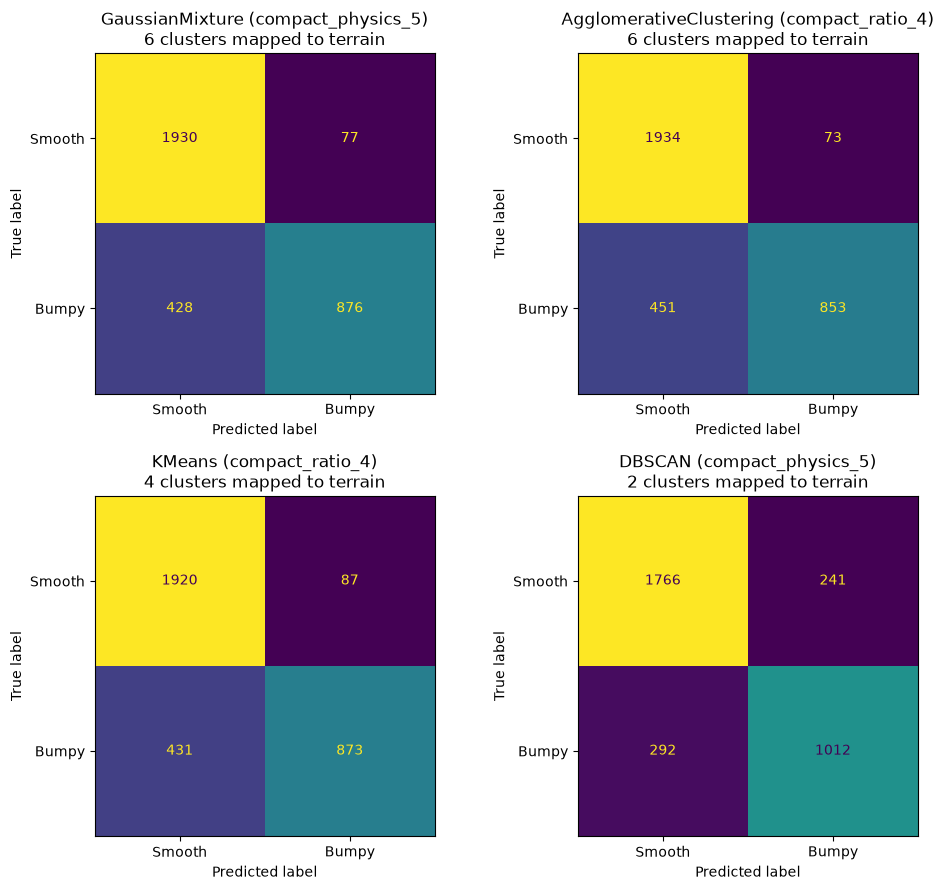

In [14]:
from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

unsupervised_pipelines = init_model_pipelines("Unsupervised")

figure, subplot_grid = plt.subplots(2, 2, figsize=(10, 9))

for subplot, best_model in zip(subplot_grid.ravel(), best_cluster_results_df.itertuples()):

    train_features = train_df[model_features_data[best_model.feature_set]]

    # Rebuild the winning pipeline and cluster the training windows again
    pipeline = clone(unsupervised_pipelines[best_model.model]).set_params(**best_model.params)
    cluster_labels = pipeline.fit_predict(train_features)

    # Label every cluster with its majority terrain, same as in evaluate_clustering
    terrain_by_cluster = pd.Series(y_train.to_numpy()).groupby(cluster_labels)
    majority_terrain = terrain_by_cluster.agg(lambda terrain: terrain.mode()[0])
    predicted_labels = majority_terrain.loc[cluster_labels].to_numpy()

    confusion = confusion_matrix(y_train, predicted_labels, labels=[0, 1])
    ConfusionMatrixDisplay(confusion, display_labels=["Smooth", "Bumpy"]).plot(
        ax=subplot, colorbar=False, values_format="d")
    subplot.set_title(f"{best_model.model} ({best_model.feature_set})\n"
                      f"{best_model.n_clusters} clusters mapped to terrain")

plt.tight_layout()
plt.show()

# Run on test data set